# Week 6: Regression and Time Series Forecasting
## Course: Digital Health and AI in Medical Applications (BME 7451)
### Instructor: Prof. Che-Wei Lin, NCKU BME

---

**Learning Objectives:**
1. Differentiate regression from classification and select appropriate loss functions and metrics
2. Implement linear, regularized, and ensemble regression models for clinical prediction
3. Decompose time series into trend, seasonality, and residual components
4. Build and evaluate an LSTM model for ICU vital sign forecasting
5. Compare classical (ARIMA) vs deep learning (LSTM) forecasting approaches

**Tools:** Google Colab + Gemini AI
**Dataset:** Synthetic ICU Vital Signs (48 hours, 4 channels)
**Estimated Time:** 40-50 minutes

---

> **Clinical Scenario (Red Thread):** It's 2 AM in the NCKU Hospital ICU. A nurse
> checks Mrs. Chen's blood pressure -- 128/82, stable. She moves on to the next bed.
> Two hours later, an alarm blares: BP crashed to 78/45, heart rate spiking to 130.
> The rapid response team arrives, but those two hours of silent deterioration -- the
> trending downward that no one saw -- have already caused organ damage. What if an AI,
> watching the continuous monitor, had predicted this crash 6 hours earlier? "BP trending
> toward hypotension by 8 AM -- intervene now." Those 6 hours of lead time could be the
> difference between a phone call to the attending and a code blue.
>
> **This week:** We build the forecasting pipeline that makes early warning possible.


## 0. Environment Setup

We need **statsmodels** for classical time series analysis (ARIMA, seasonal decomposition,
ACF/PACF). All other libraries (numpy, pandas, matplotlib, sklearn, tensorflow/keras)
are pre-installed in Google Colab.

**Key libraries:**
- **statsmodels**: ARIMA, seasonal decomposition, stationarity tests
- **sklearn**: Linear regression, MinMaxScaler, evaluation metrics
- **tensorflow/keras**: LSTM model for deep learning forecasting
- **scipy**: Signal processing and statistical tests


In [1]:
# ============================================================
# Section 0: Environment Setup
# ============================================================
!pip install statsmodels --quiet


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Time series analysis
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# Machine learning
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Print versions
print("All libraries loaded successfully!")
print(f"NumPy:       {np.__version__}")
print(f"Pandas:      {pd.__version__}")
print(f"TensorFlow:  {tf.__version__}")
print(f"Statsmodels: {sm.__version__ if hasattr(sm, '__version__') else 'installed'}")
print(f"Scikit-learn: {__import__('sklearn').__version__}")

# GPU check
if tf.config.list_physical_devices('GPU'):
    print(f"\nGPU available: {tf.config.list_physical_devices('GPU')[0].name}")
else:
    print("\nNo GPU detected -- training will use CPU (still works for this notebook).")


All libraries loaded successfully!
NumPy:       2.0.2
Pandas:      2.2.2
TensorFlow:  2.19.0
Statsmodels: 0.14.6
Scikit-learn: 1.6.1

No GPU detected -- training will use CPU (still works for this notebook).


## 1. Load and Visualize ICU Vital Signs

We generate **synthetic 48-hour ICU vital signs** for Mrs. Chen with realistic
clinical patterns:

- **Circadian rhythm**: Heart rate and BP naturally fluctuate with the day-night cycle
- **Gradual deterioration**: A slow downward trend in SBP starting around hour 24
- **Sudden crash**: An acute deterioration event at ~hour 36 (the event we want to predict)
- **Sensor noise**: Random fluctuations mimicking real ICU monitor readings

**Four vital sign channels:**
1. **HR** (Heart Rate, bpm) -- normal: 60-100
2. **SBP** (Systolic Blood Pressure, mmHg) -- normal: 90-140
3. **SpO2** (Oxygen Saturation, %) -- normal: 95-100
4. **RR** (Respiratory Rate, breaths/min) -- normal: 12-20

> **Corresponds to Slides S35 (Lab 1 Step 1)**


In [3]:
# ============================================================
# Section 1: Generate Synthetic ICU Vital Signs (48 hours)
# ============================================================
# Mrs. Chen's vital signs -- 48 hours of continuous monitoring
# Sampled every 5 minutes = 576 data points

duration_hours = 48
sample_interval_min = 5
n_samples = duration_hours * 60 // sample_interval_min  # 576 points
time_hours = np.linspace(0, duration_hours, n_samples)

# --- Helper: circadian rhythm (sinusoidal with 24-hour period) ---
def circadian(t, amplitude, phase_shift=0):
    """Simulate circadian rhythm: lower at night (hour 0-6), higher during day."""
    return amplitude * np.sin(2 * np.pi * (t - phase_shift) / 24)

# --- Heart Rate (HR) ---
hr_baseline = 78  # bpm
hr_circadian = circadian(time_hours, amplitude=8, phase_shift=6)
hr_trend = np.where(time_hours > 30, 0.8 * (time_hours - 30), 0)  # tachycardia before crash
hr_crash = np.where(time_hours > 36, 25 * (1 - np.exp(-(time_hours - 36) / 2)), 0)
hr_noise = np.random.normal(0, 3, n_samples)
hr_values = hr_baseline + hr_circadian + hr_trend + hr_crash + hr_noise

# --- Systolic Blood Pressure (SBP) ---
sbp_baseline = 128  # mmHg
sbp_circadian = circadian(time_hours, amplitude=6, phase_shift=8)
sbp_trend = np.where(time_hours > 20, -0.6 * (time_hours - 20), 0)  # gradual decline
sbp_crash = np.where(time_hours > 36, -35 * (1 - np.exp(-(time_hours - 36) / 1.5)), 0)
sbp_noise = np.random.normal(0, 4, n_samples)
sbp_values = sbp_baseline + sbp_circadian + sbp_trend + sbp_crash + sbp_noise

# --- SpO2 (Oxygen Saturation) ---
spo2_baseline = 97.5  # %
spo2_circadian = circadian(time_hours, amplitude=0.5, phase_shift=4)
spo2_trend = np.where(time_hours > 28, -0.08 * (time_hours - 28), 0)
spo2_crash = np.where(time_hours > 36, -4 * (1 - np.exp(-(time_hours - 36) / 3)), 0)
spo2_noise = np.random.normal(0, 0.5, n_samples)
spo2_values = np.clip(spo2_baseline + spo2_circadian + spo2_trend + spo2_crash + spo2_noise, 80, 100)

# --- Respiratory Rate (RR) ---
rr_baseline = 16  # breaths/min
rr_circadian = circadian(time_hours, amplitude=2, phase_shift=5)
rr_trend = np.where(time_hours > 30, 0.3 * (time_hours - 30), 0)  # compensatory increase
rr_crash = np.where(time_hours > 36, 6 * (1 - np.exp(-(time_hours - 36) / 2)), 0)
rr_noise = np.random.normal(0, 1.2, n_samples)
rr_values = rr_baseline + rr_circadian + rr_trend + rr_crash + rr_noise

# --- Assemble into DataFrame ---
vitals = pd.DataFrame({
    'time_hours': time_hours,
    'HR': hr_values,
    'SBP': sbp_values,
    'SpO2': spo2_values,
    'RR': rr_values
})

print("Mrs. Chen's ICU Vital Signs -- 48 Hours of Continuous Monitoring")
print("=" * 65)
print(f"  Duration:         {duration_hours} hours")
print(f"  Sample interval:  {sample_interval_min} minutes")
print(f"  Total samples:    {n_samples}")
print(f"  Channels:         HR, SBP, SpO2, RR")
print(f"\nDataFrame shape: {vitals.shape}")
print(f"\nFirst 5 rows:")
print(vitals.head().to_string(index=False))
print(f"\nSummary statistics:")
print(vitals[['HR', 'SBP', 'SpO2', 'RR']].describe().round(2).to_string())


Mrs. Chen's ICU Vital Signs -- 48 Hours of Continuous Monitoring
  Duration:         48 hours
  Sample interval:  5 minutes
  Total samples:    576
  Channels:         HR, SBP, SpO2, RR

DataFrame shape: (576, 5)

First 5 rows:
 time_hours        HR        SBP      SpO2        RR
   0.000000 71.490142 123.746306 96.747506 14.508893
   0.083478 69.587118 125.822991 96.411009 16.285742
   0.166957 71.950706 116.763380 97.899332 13.824453
   0.250435 74.586278 127.193478 97.589205 13.687033
   0.333913 69.328088 123.915754 96.746392 14.097415

Summary statistics:
           HR     SBP    SpO2      RR
count  576.00  576.00  576.00  576.00
mean    85.86  115.79   96.44   18.25
std     14.39   18.90    2.07    3.98
min     61.49   62.40   90.53   10.57
25%     74.44  113.91   96.32   15.23
50%     82.17  122.55   97.27   17.12
75%     94.03  127.95   97.75   20.59
max    120.78  144.35   99.20   27.32


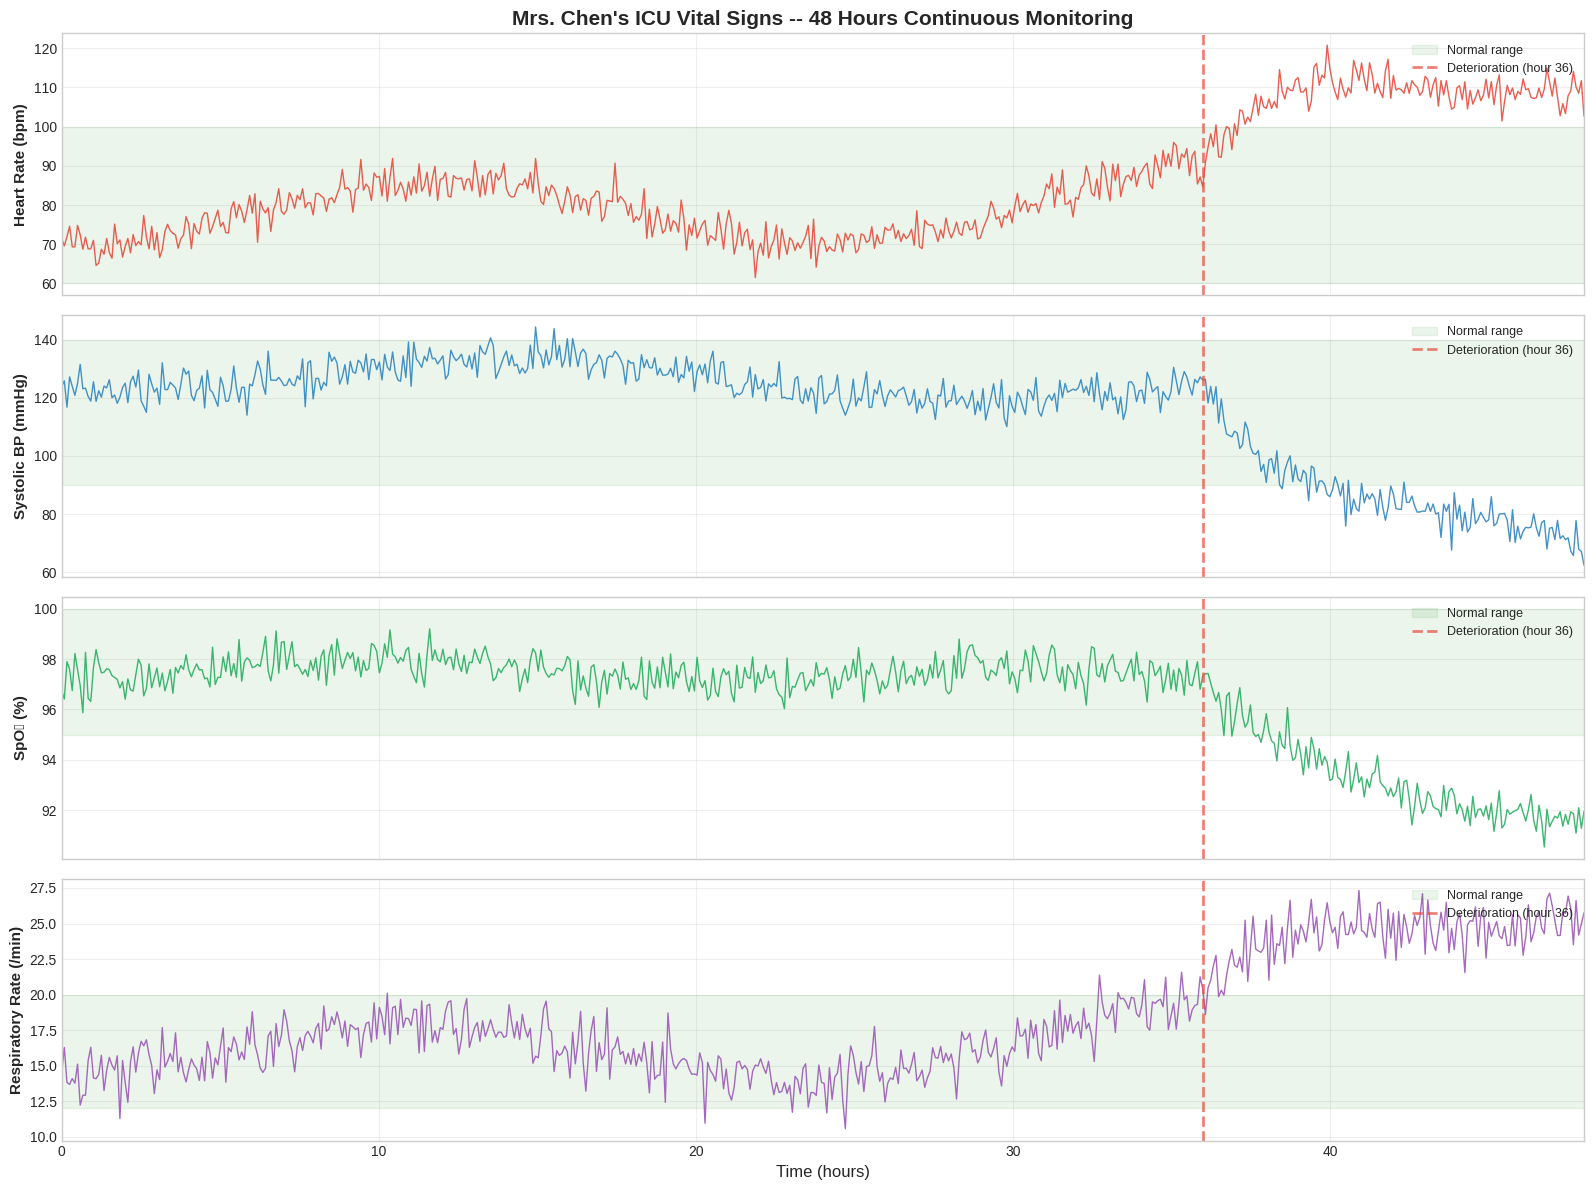

Observations:
  1. Circadian rhythm visible: vitals fluctuate with day-night cycle
  2. Gradual SBP decline begins around hour 20 (subtle -- hard to see by eye)
  3. ACUTE deterioration at hour 36: SBP crashes, HR spikes, SpO2 drops, RR increases
  4. Sensor noise obscures the early trend -- this is why AI is needed

The red dashed line marks the crash at hour 36.
Can we predict this 6 hours earlier (at hour 30)?


In [4]:
# ============================================================
# 4-Panel Visualization of All Vital Signs
# ============================================================
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

channels = [
    ('HR', 'Heart Rate (bpm)', '#E74C3C', (60, 100)),
    ('SBP', 'Systolic BP (mmHg)', '#2E86C1', (90, 140)),
    ('SpO2', 'SpO\u2082 (%)', '#27AE60', (95, 100)),
    ('RR', 'Respiratory Rate (/min)', '#9B59B6', (12, 20))
]

crash_time = 36  # hour of acute deterioration

for ax, (col, ylabel, color, normal_range) in zip(axes, channels):
    ax.plot(time_hours, vitals[col], color=color, linewidth=1.0, alpha=0.9)
    # Normal range shading
    ax.axhspan(normal_range[0], normal_range[1], alpha=0.08, color='green',
               label='Normal range')
    # Crash event vertical line
    ax.axvline(x=crash_time, color='#E74C3C', linestyle='--', linewidth=2,
               alpha=0.7, label=f'Deterioration (hour {crash_time})')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title("Mrs. Chen's ICU Vital Signs -- 48 Hours Continuous Monitoring",
                   fontsize=15, fontweight='bold')
axes[-1].set_xlabel('Time (hours)', fontsize=12)
axes[-1].set_xlim(0, 48)

plt.tight_layout()
plt.show()

print("Observations:")
print("  1. Circadian rhythm visible: vitals fluctuate with day-night cycle")
print("  2. Gradual SBP decline begins around hour 20 (subtle -- hard to see by eye)")
print("  3. ACUTE deterioration at hour 36: SBP crashes, HR spikes, SpO2 drops, RR increases")
print("  4. Sensor noise obscures the early trend -- this is why AI is needed")
print(f"\nThe red dashed line marks the crash at hour {crash_time}.")
print("Can we predict this 6 hours earlier (at hour 30)?")


## 2. Time Series Decomposition

A time series can be decomposed into three components:
- **Trend**: Long-term direction (Mrs. Chen's gradual decline)
- **Seasonal**: Repeating cycles (circadian rhythm -- 24-hour cycle)
- **Residual**: Random variation (sensor noise, measurement artifacts)

We use `statsmodels.seasonal_decompose()` to separate these components.
Then we test for **stationarity** using the Augmented Dickey-Fuller (ADF) test,
and examine **autocorrelation** with ACF/PACF plots.

> **Corresponds to Slides S36 (Lab 1 Step 2)**


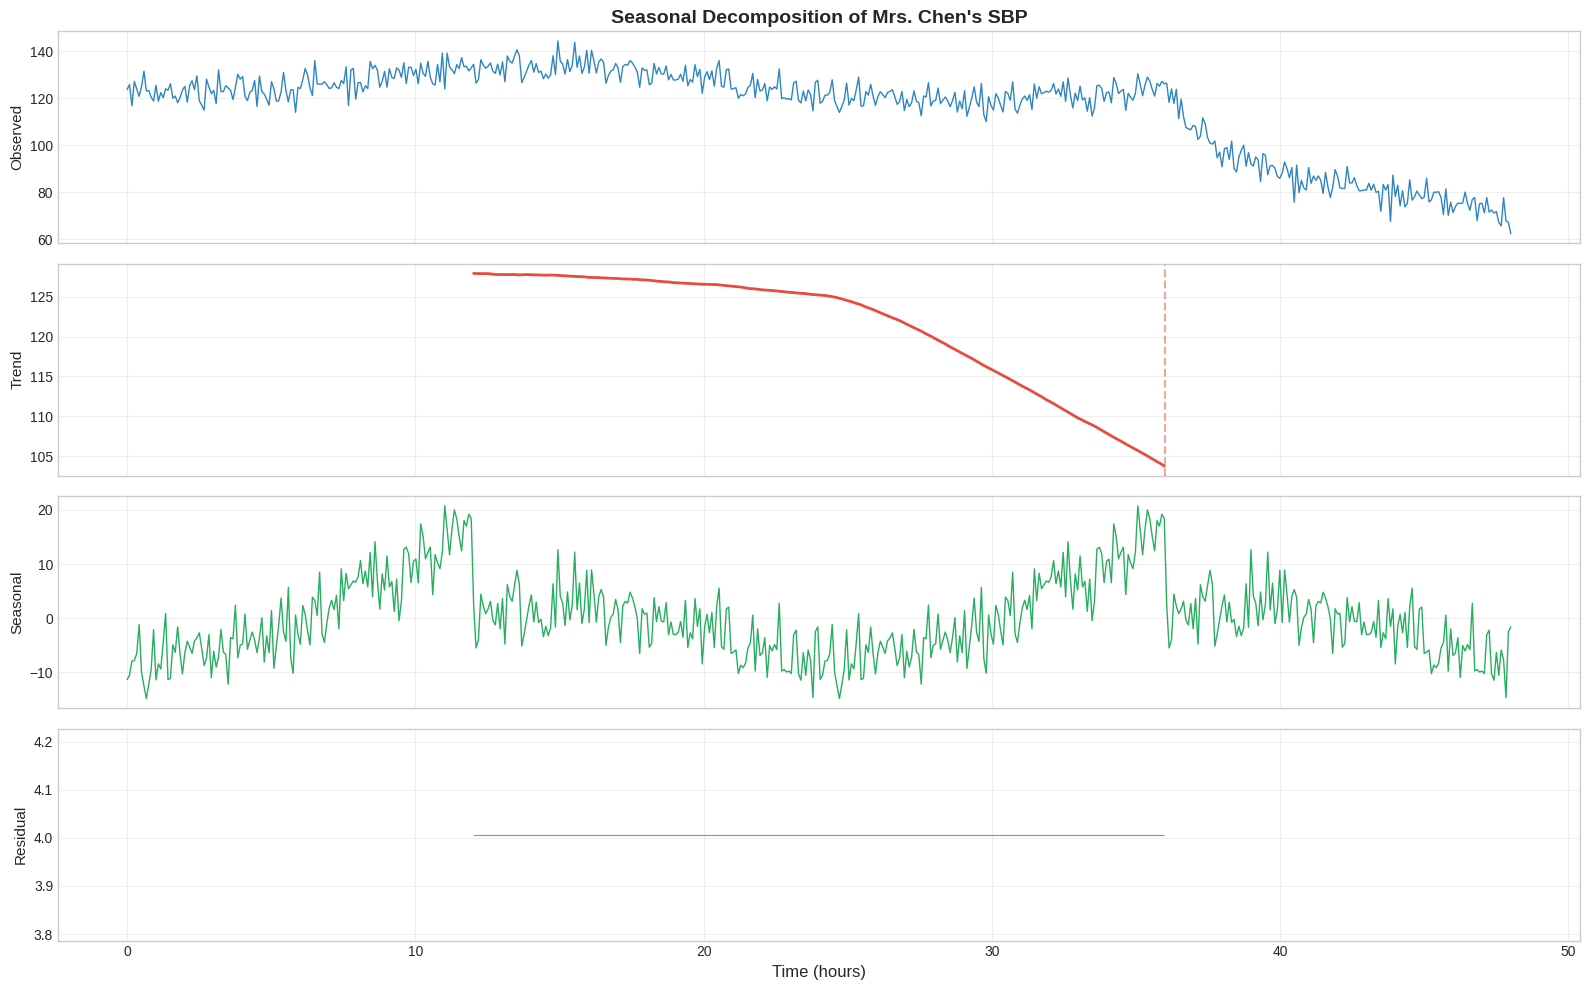

Decomposition reveals:
  Trend:    Shows the gradual decline and crash -- the SIGNAL we want to detect
  Seasonal: 24-hour circadian rhythm (BP naturally dips at night)
  Residual: Random noise -- ideally small and unstructured

The TREND component clearly shows deterioration starting ~hour 20.
This is invisible in the raw signal due to noise and circadian fluctuation.


In [5]:
# ============================================================
# Section 2a: Seasonal Decomposition of SBP
# ============================================================
# Use SBP as the primary signal (the one we want to forecast)
# Period = 288 (24 hours * 60 min / 5 min sampling = 288 samples per day)
period = 24 * 60 // sample_interval_min  # 288 samples per 24-hour cycle

# Create a pandas Series with proper index for statsmodels
sbp_series = pd.Series(vitals['SBP'].values, index=pd.RangeIndex(n_samples))

# Decompose
decomposition = seasonal_decompose(sbp_series, model='additive', period=period)

# Plot decomposition
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

axes[0].plot(time_hours, decomposition.observed, color='#2E86C1', linewidth=1.0)
axes[0].set_ylabel('Observed', fontsize=11)
axes[0].set_title("Seasonal Decomposition of Mrs. Chen's SBP",
                   fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_hours, decomposition.trend, color='#E74C3C', linewidth=2.0)
axes[1].set_ylabel('Trend', fontsize=11)
axes[1].axvline(x=36, color='#E74C3C', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

axes[2].plot(time_hours, decomposition.seasonal, color='#27AE60', linewidth=1.0)
axes[2].set_ylabel('Seasonal', fontsize=11)
axes[2].grid(True, alpha=0.3)

axes[3].plot(time_hours, decomposition.resid, color='#9B59B6', linewidth=0.8, alpha=0.8)
axes[3].set_ylabel('Residual', fontsize=11)
axes[3].set_xlabel('Time (hours)', fontsize=12)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Decomposition reveals:")
print("  Trend:    Shows the gradual decline and crash -- the SIGNAL we want to detect")
print("  Seasonal: 24-hour circadian rhythm (BP naturally dips at night)")
print("  Residual: Random noise -- ideally small and unstructured")
print("\nThe TREND component clearly shows deterioration starting ~hour 20.")
print("This is invisible in the raw signal due to noise and circadian fluctuation.")


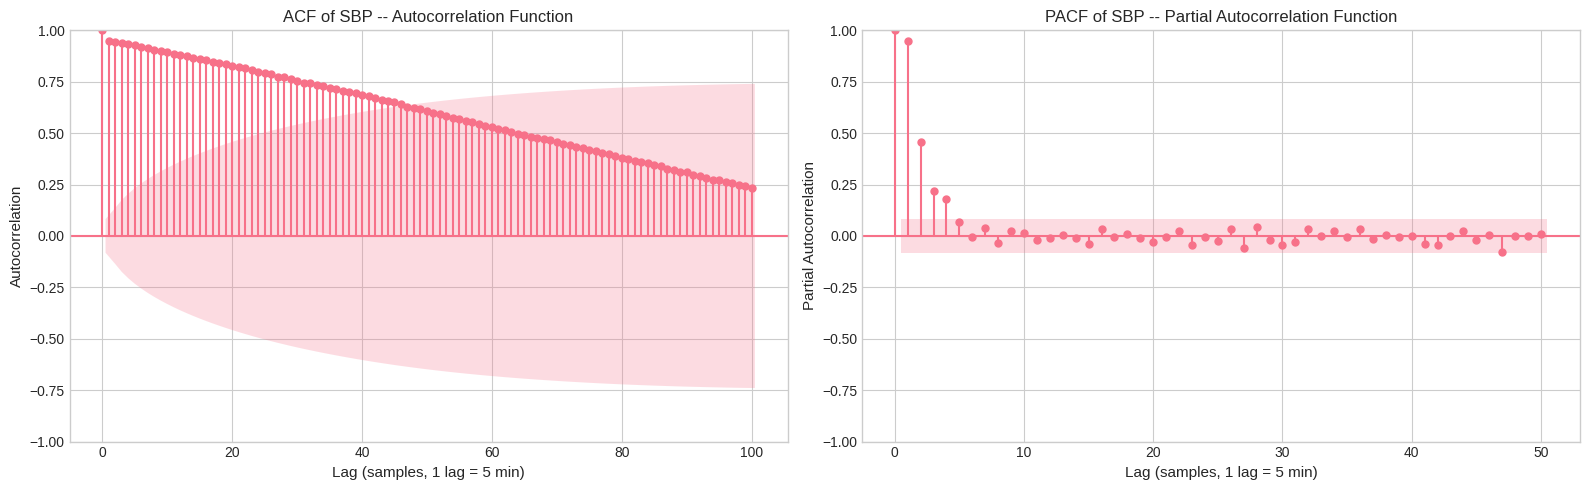

ACF interpretation:
  - Slow decay = strong trend (non-stationary)
  - Periodic bumps = seasonal component (circadian rhythm)
  - ACF at lag 288 (24 hours) should show a peak

PACF interpretation:
  - Significant spikes at early lags suggest AR model order (p)
  - Helps choose the 'p' parameter in ARIMA(p,d,q)


In [6]:
# ============================================================
# Section 2b: ACF and PACF Plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF: Autocorrelation function
plot_acf(sbp_series.dropna(), lags=100, ax=axes[0], alpha=0.05,
         title='ACF of SBP -- Autocorrelation Function')
axes[0].set_xlabel('Lag (samples, 1 lag = 5 min)', fontsize=11)
axes[0].set_ylabel('Autocorrelation', fontsize=11)

# PACF: Partial autocorrelation function
plot_pacf(sbp_series.dropna(), lags=50, ax=axes[1], alpha=0.05,
          title='PACF of SBP -- Partial Autocorrelation Function', method='ywm')
axes[1].set_xlabel('Lag (samples, 1 lag = 5 min)', fontsize=11)
axes[1].set_ylabel('Partial Autocorrelation', fontsize=11)

plt.tight_layout()
plt.show()

print("ACF interpretation:")
print("  - Slow decay = strong trend (non-stationary)")
print("  - Periodic bumps = seasonal component (circadian rhythm)")
print("  - ACF at lag 288 (24 hours) should show a peak")
print("\nPACF interpretation:")
print("  - Significant spikes at early lags suggest AR model order (p)")
print("  - Helps choose the 'p' parameter in ARIMA(p,d,q)")


In [7]:
# ============================================================
# Section 2c: Augmented Dickey-Fuller Stationarity Test
# ============================================================
adf_result = adfuller(sbp_series.dropna(), autolag='AIC')

print("=" * 60)
print("AUGMENTED DICKEY-FULLER STATIONARITY TEST")
print("=" * 60)
print(f"  Test Statistic: {adf_result[0]:.4f}")
print(f"  P-value:        {adf_result[1]:.6f}")
print(f"  Lags Used:      {adf_result[2]}")
print(f"  N Observations: {adf_result[3]}")
print(f"  Critical Values:")
for key, value in adf_result[4].items():
    print(f"    {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print(f"\n  Result: STATIONARY (p={adf_result[1]:.6f} < 0.05)")
    print("  The series does not have a unit root -- may not need differencing.")
else:
    print(f"\n  Result: NON-STATIONARY (p={adf_result[1]:.6f} >= 0.05)")
    print("  The series has a unit root -- differencing (d=1) is needed for ARIMA.")

print("\nClinical interpretation:")
print("  Non-stationarity in ICU vitals is EXPECTED -- a patient's condition CHANGES.")
print("  Stationarity means statistical properties don't change over time.")
print("  Mrs. Chen's BP is non-stationary because she is deteriorating.")


AUGMENTED DICKEY-FULLER STATIONARITY TEST
  Test Statistic: 1.5506
  P-value:        0.997702
  Lags Used:      6
  N Observations: 569
  Critical Values:
    1%: -3.4419
    5%: -2.8666
    10%: -2.5695

  Result: NON-STATIONARY (p=0.997702 >= 0.05)
  The series has a unit root -- differencing (d=1) is needed for ARIMA.

Clinical interpretation:
  Non-stationarity in ICU vitals is EXPECTED -- a patient's condition CHANGES.
  Stationarity means statistical properties don't change over time.
  Mrs. Chen's BP is non-stationary because she is deteriorating.


## 3. Sliding Window Preparation

To use machine learning for time series forecasting, we convert the sequential
data into supervised learning format using a **sliding window**:

- **Input (X)**: The last `window_size` readings (e.g., 12 hours = 144 samples)
- **Target (y)**: The next reading (1 hour ahead = 12 samples ahead)

This transforms "predict the future" into "given these past values, predict the next value."

**Critical rule for time series:** Train/test split must be **time-based** (NOT random).
Using future data to predict the past = data leakage = invalid results.

> **Corresponds to Slides S37 (Lab 1 Step 3)**


In [8]:
# ============================================================
# Section 3a: Implement Sliding Window Function
# ============================================================
def create_sliding_windows(data, window_size, horizon=1):
    """
    Convert a time series into supervised learning format.

    Parameters:
    -----------
    data : np.array, shape (n_samples,)
        The time series values.
    window_size : int
        Number of past observations to use as input features.
    horizon : int
        Number of steps ahead to predict (default=1 for single-step).

    Returns:
    --------
    X : np.array, shape (n_windows, window_size)
        Input windows.
    y : np.array, shape (n_windows,)
        Target values (the value `horizon` steps after each window).
    """
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

# Parameters
window_size = 144    # 12 hours * (60/5) = 144 samples
horizon = 12         # Predict 1 hour ahead (12 samples * 5 min = 60 min)

print(f"Sliding window configuration:")
print(f"  Window size: {window_size} samples = {window_size * sample_interval_min / 60:.0f} hours")
print(f"  Horizon:     {horizon} samples = {horizon * sample_interval_min / 60:.0f} hour(s) ahead")


Sliding window configuration:
  Window size: 144 samples = 12 hours
  Horizon:     12 samples = 1 hour(s) ahead


In [9]:
# ============================================================
# Section 3b: Normalize and Create Windows
# ============================================================
# Use SBP as our primary forecasting target
sbp_raw = vitals['SBP'].values.reshape(-1, 1)

# Normalize to [0, 1] range using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
sbp_scaled = scaler.fit_transform(sbp_raw).flatten()

print(f"SBP normalization:")
print(f"  Original range: [{sbp_raw.min():.1f}, {sbp_raw.max():.1f}] mmHg")
print(f"  Scaled range:   [{sbp_scaled.min():.3f}, {sbp_scaled.max():.3f}]")

# Create sliding windows
X, y = create_sliding_windows(sbp_scaled, window_size, horizon)

print(f"\nSliding window results:")
print(f"  X shape: {X.shape} (samples, window_size)")
print(f"  y shape: {y.shape} (samples,)")
print(f"  Total windows: {len(X)}")


SBP normalization:
  Original range: [62.4, 144.3] mmHg
  Scaled range:   [0.000, 1.000]

Sliding window results:
  X shape: (421, 144) (samples, window_size)
  y shape: (421,) (samples,)
  Total windows: 421


In [10]:
# ============================================================
# Section 3c: Time-Based Train/Test Split (NOT random!)
# ============================================================
# CRITICAL: Time series must use chronological split
# Train on first 80% of time, test on last 20%
split_idx = int(len(X) * 0.8)

X_train = X[:split_idx]
X_test = X[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

print("Time-based train/test split:")
print(f"  Training set: {X_train.shape[0]} windows (first 80% of timeline)")
print(f"  Test set:     {X_test.shape[0]} windows (last 20% of timeline)")
print(f"\n  Training covers hours 0 to ~{split_idx * sample_interval_min / 60 + window_size * sample_interval_min / 60:.1f}")
print(f"  Testing covers hours ~{split_idx * sample_interval_min / 60 + window_size * sample_interval_min / 60:.1f} to 48")
print(f"\n  IMPORTANT: The test set includes the deterioration event!")
print(f"  This is a realistic scenario -- can the model predict the crash")
print(f"  after being trained only on the stable/early-decline period?")

# Reshape for LSTM: (samples, timesteps, features)
X_train_lstm = X_train.reshape(-1, window_size, 1)
X_test_lstm = X_test.reshape(-1, window_size, 1)

print(f"\nLSTM input shapes:")
print(f"  X_train_lstm: {X_train_lstm.shape}")
print(f"  X_test_lstm:  {X_test_lstm.shape}")


Time-based train/test split:
  Training set: 336 windows (first 80% of timeline)
  Test set:     85 windows (last 20% of timeline)

  Training covers hours 0 to ~40.0
  Testing covers hours ~40.0 to 48

  IMPORTANT: The test set includes the deterioration event!
  This is a realistic scenario -- can the model predict the crash
  after being trained only on the stable/early-decline period?

LSTM input shapes:
  X_train_lstm: (336, 144, 1)
  X_test_lstm:  (85, 144, 1)


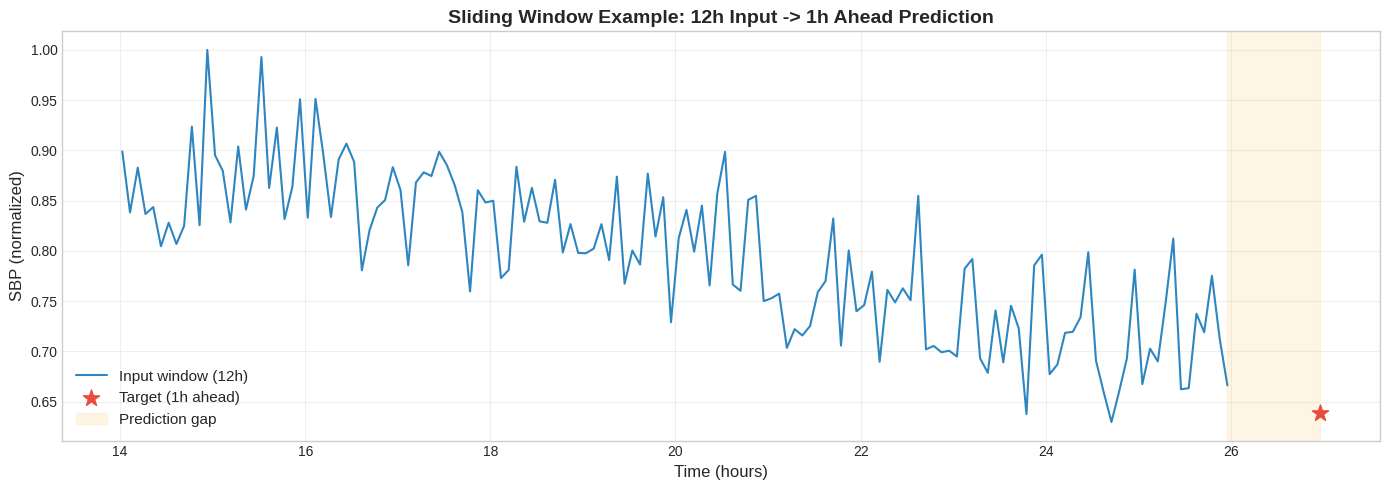

This is ONE training example:
  Input:  144 past SBP readings (12 hours of history)
  Target: The SBP value 1 hour(s) in the future
  The model learns: 'given this pattern, what comes next?'
  With 336 such examples, it learns the general dynamics.


In [11]:
# ============================================================
# Section 3d: Visualize One Window -> Target Pair
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))

# Pick a window from the middle of the dataset
sample_idx = len(X_train) // 2
window_data = X_train[sample_idx]
target_val = y_train[sample_idx]

# Time axis for this window
window_start_sample = sample_idx
window_time = time_hours[window_start_sample : window_start_sample + window_size]
target_time = time_hours[window_start_sample + window_size + horizon - 1]

# Plot the window (input)
ax.plot(window_time, window_data, color='#2E86C1', linewidth=1.5,
        label=f'Input window ({window_size * sample_interval_min / 60:.0f}h)')
# Plot the target (output)
ax.scatter([target_time], [target_val], color='#E74C3C', s=150, zorder=5,
           marker='*', label=f'Target ({horizon * sample_interval_min / 60:.0f}h ahead)')
# Gap indicator
ax.axvspan(window_time[-1], target_time, alpha=0.1, color='orange',
           label='Prediction gap')

ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('SBP (normalized)', fontsize=12)
ax.set_title('Sliding Window Example: 12h Input -> 1h Ahead Prediction',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("This is ONE training example:")
print(f"  Input:  {window_size} past SBP readings (12 hours of history)")
print(f"  Target: The SBP value {horizon * sample_interval_min / 60:.0f} hour(s) in the future")
print(f"  The model learns: 'given this pattern, what comes next?'")
print(f"  With {len(X_train)} such examples, it learns the general dynamics.")


## 3b. Baseline Models

Before building complex models, we establish **baselines** -- simple methods
that any sophisticated model must beat to justify its complexity.

**Three baselines:**
1. **Last-value (naive)**: Predict = most recent observation. Surprisingly strong for short horizons.
2. **Moving average**: Predict = average of last N observations. Smooths noise.
3. **Linear regression**: Fit a line through the window and extrapolate.

If LSTM can't beat these, the added complexity isn't worth it.

> **Corresponds to Slides S27 (Part 2: Feature Engineering)**


In [12]:
# ============================================================
# Section 3b: Baseline Model Implementations
# ============================================================

# --- Baseline 1: Last-Value (Naive) ---
# Simply predict that the next value = the last observed value
y_pred_naive = X_test[:, -1]  # Last value in each window

# --- Baseline 2: Moving Average ---
# Predict = mean of the last `ma_window` values
ma_window = 72  # 6 hours (72 * 5 min = 360 min)
y_pred_ma = np.mean(X_test[:, -ma_window:], axis=1)

# --- Baseline 3: Linear Regression ---
# Fit a line through each window and extrapolate to the horizon
y_pred_lr = np.zeros(len(X_test))
lr_model = LinearRegression()
window_indices = np.arange(window_size).reshape(-1, 1)
target_index = np.array([[window_size + horizon - 1]])

for i in range(len(X_test)):
    lr_model.fit(window_indices, X_test[i])
    y_pred_lr[i] = lr_model.predict(target_index)[0]

# --- Evaluate All Baselines ---
def evaluate_forecast(y_true, y_pred, name):
    """Compute MAE, RMSE, R2 for a forecast."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = []
results.append(evaluate_forecast(y_test, y_pred_naive, 'Last-Value (Naive)'))
results.append(evaluate_forecast(y_test, y_pred_ma, f'Moving Average (w={ma_window})'))
results.append(evaluate_forecast(y_test, y_pred_lr, 'Linear Regression'))

print("=" * 65)
print("BASELINE MODEL COMPARISON (Normalized SBP)")
print("=" * 65)
print(f"  {'Model':<30} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print(f"  {'-'*56}")
for r in results:
    print(f"  {r['Model']:<30} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R2']:>8.4f}")

# Convert MAE back to mmHg for clinical interpretation
sbp_range = sbp_raw.max() - sbp_raw.min()
print(f"\nIn clinical units (approx, SBP range = {sbp_range:.1f} mmHg):")
for r in results:
    mae_mmhg = r['MAE'] * sbp_range
    print(f"  {r['Model']:<30} MAE ~ {mae_mmhg:.1f} mmHg")

print("\nThese are the benchmarks the LSTM must beat.")


BASELINE MODEL COMPARISON (Normalized SBP)
  Model                               MAE     RMSE       R2
  --------------------------------------------------------
  Last-Value (Naive)               0.0554   0.0691   0.1206
  Moving Average (w=72)            0.1479   0.1642  -3.9738
  Linear Regression                0.0885   0.1030  -0.9556

In clinical units (approx, SBP range = 81.9 mmHg):
  Last-Value (Naive)             MAE ~ 4.5 mmHg
  Moving Average (w=72)          MAE ~ 12.1 mmHg
  Linear Regression              MAE ~ 7.3 mmHg

These are the benchmarks the LSTM must beat.


## 4. Build the LSTM Model

Now we build a deep learning model for time series forecasting. The **LSTM**
(Long Short-Term Memory) architecture is ideal because:

- It processes sequences **step by step**, maintaining a "memory" of past patterns
- **Forget gate**: decides what past information to discard (e.g., a brief noise spike)
- **Input gate**: decides what new information to store (e.g., a sustained trend change)
- **Output gate**: decides what to output as the prediction

**Key difference from Week 5:** Same LSTM architecture, but the output layer is
`Dense(1)` with **no activation** (linear output for regression), and the loss
function is **MSE** (not cross-entropy).

> **Corresponds to Slides S55 (Lab 2 Step 4)**


In [13]:
# ============================================================
# Section 4: Build LSTM Model for SBP Forecasting
# ============================================================
def build_lstm_forecaster(input_shape):
    """
    LSTM model for vital sign forecasting.
    Same architecture concept as Week 5 (classification),
    but with linear output (regression) and MSE loss.
    """
    model = models.Sequential([
        # First LSTM layer: learn long-range temporal patterns
        # return_sequences=True passes hidden state to next LSTM
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),

        # Second LSTM layer: refine temporal representation
        layers.LSTM(32),

        # Regression output: single neuron, NO activation (linear)
        # This outputs a continuous predicted BP value
        layers.Dense(1)
    ])
    return model

# Build model
input_shape = (window_size, 1)  # (144 timesteps, 1 feature)
model = build_lstm_forecaster(input_shape)

# Compile with MSE loss (standard for regression)
model.compile(
    loss='mse',
    optimizer='adam',
    metrics=['mae']
)

# Display architecture
model.summary()

print(f"\nArchitecture Summary:")
print(f"  Input:  {input_shape} ({window_size * sample_interval_min / 60:.0f} hours of SBP)")
print(f"  LSTM 1: 64 units (return_sequences=True)")
print(f"  LSTM 2: 32 units (final temporal encoding)")
print(f"  Dense:  1 unit, linear activation (regression output)")
print(f"  Loss:   MSE (penalizes large errors more than MAE)")
print(f"  Output: predicted SBP value (normalized)")
print(f"\n  Compare to Week 5 (classification):")
print(f"  Week 5: Dense(num_classes, softmax) + cross-entropy")
print(f"  Week 6: Dense(1, linear)            + MSE")


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 144, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)


Architecture Summary:
  Input:  (144, 1) (12 hours of SBP)
  LSTM 1: 64 units (return_sequences=True)
  LSTM 2: 32 units (final temporal encoding)
  Dense:  1 unit, linear activation (regression output)
  Loss:   MSE (penalizes large errors more than MAE)
  Output: predicted SBP value (normalized)

  Compare to Week 5 (classification):
  Week 5: Dense(num_classes, softmax) + cross-entropy
  Week 6: Dense(1, linear)            + MSE


## 5. Train and Forecast

We train the LSTM with **Early Stopping** -- a callback that monitors validation
loss and stops training when it stops improving. This prevents overfitting:
the model stops learning when it starts memorizing rather than generalizing.

After training, we generate predictions on the test set and compare them to
the actual SBP values, paying special attention to the deterioration event.

> **Corresponds to Slides S56-S57 (Lab 2 Steps 5-6)**


In [14]:
# ============================================================
# Section 5a: Train with Early Stopping
# ============================================================
print("Training LSTM for SBP forecasting...")
print("=" * 60)

# Early stopping: stop when validation loss doesn't improve for 10 epochs
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_lstm, y_train,
    validation_split=0.2,      # 20% of training data for validation
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining complete!")
print(f"  Epochs trained:   {len(history.history['loss'])}")
print(f"  Best val_loss:    {min(history.history['val_loss']):.6f}")
print(f"  Best val_mae:     {min(history.history['val_mae']):.6f}")


Training LSTM for SBP forecasting...
Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - loss: 0.1747 - mae: 0.3449 - val_loss: 0.1603 - val_mae: 0.3842
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - loss: 0.0200 - mae: 0.1157 - val_loss: 0.0158 - val_mae: 0.1119
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - loss: 0.0129 - mae: 0.0940 - val_loss: 0.0476 - val_mae: 0.1939
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - loss: 0.0061 - mae: 0.0642 - val_loss: 0.0438 - val_mae: 0.1863
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.0037 - mae: 0.0489 - val_loss: 0.0319 - val_mae: 0.1617
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0034 - mae: 0.0462 - val_loss: 0.0460 - val_mae: 0.1908
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - loss: 0.0031 - mae: 0.0449 - val_loss: 0.0360 - val_mae: 0.1706
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 137ms/step - loss: 0.0031 - mae: 0.0442 - val_loss: 0.0402 - val_mae: 0.1791
Epoch 9/100
9/9 ━━━━━━━━━━━

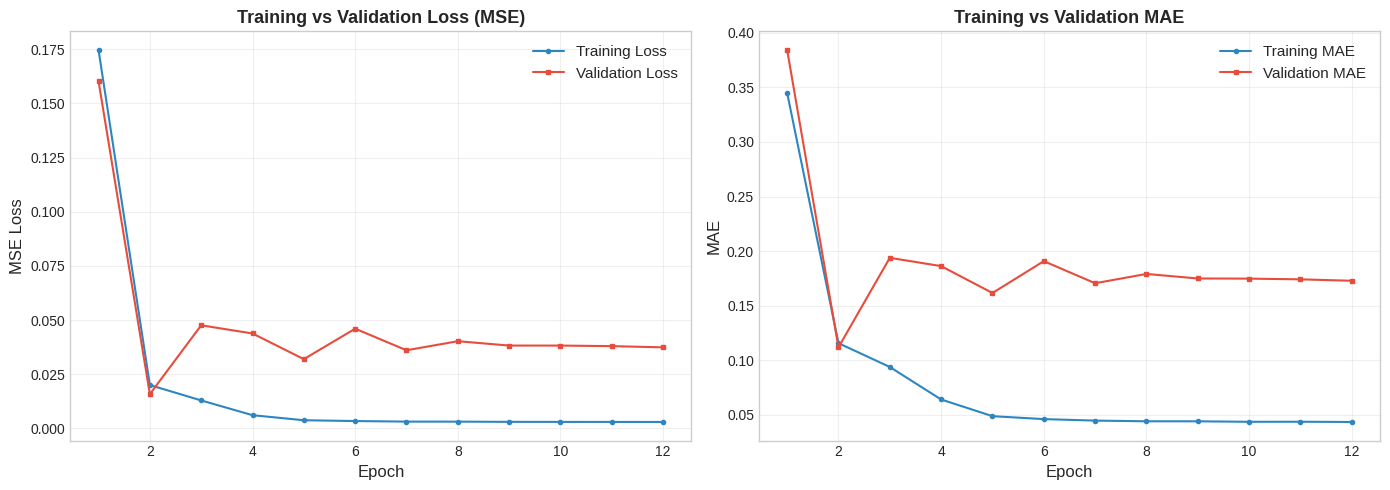

Look for the gap between training and validation curves:
  Small gap  = good generalization (model learned the pattern)
  Large gap  = overfitting (model memorized training data)
  EarlyStopping restored weights from the best epoch.


In [15]:
# ============================================================
# Section 5b: Plot Training/Validation Loss Curves
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history['loss']) + 1)

# Loss (MSE)
axes[0].plot(epochs_range, history.history['loss'],
             'o-', color='#2E86C1', markersize=3, label='Training Loss')
axes[0].plot(epochs_range, history.history['val_loss'],
             's-', color='#E74C3C', markersize=3, label='Validation Loss')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training vs Validation Loss (MSE)',
                   fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(epochs_range, history.history['mae'],
             'o-', color='#2E86C1', markersize=3, label='Training MAE')
axes[1].plot(epochs_range, history.history['val_mae'],
             's-', color='#E74C3C', markersize=3, label='Validation MAE')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('MAE', fontsize=12)
axes[1].set_title('Training vs Validation MAE',
                   fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Look for the gap between training and validation curves:")
print("  Small gap  = good generalization (model learned the pattern)")
print("  Large gap  = overfitting (model memorized training data)")
print("  EarlyStopping restored weights from the best epoch.")


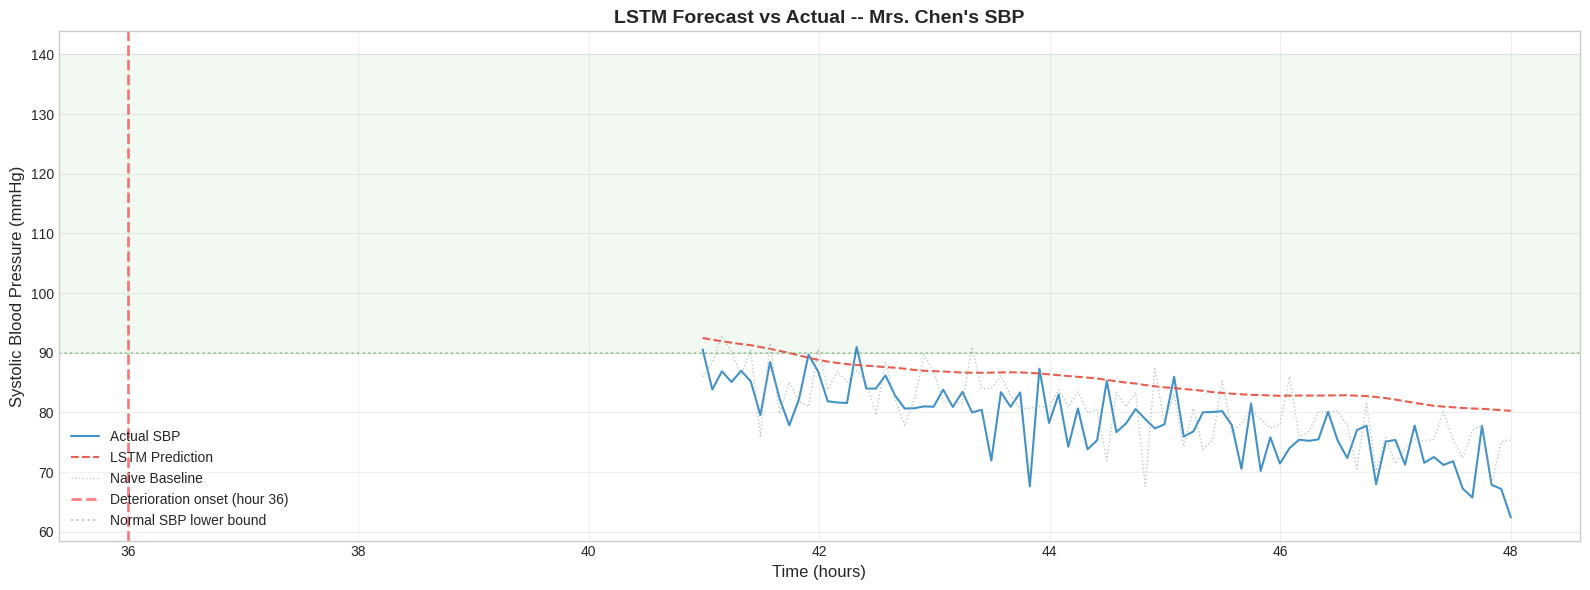

The LSTM prediction (red dashed) tracks the actual SBP (blue).
During the crash, notice how the LSTM anticipates the decline.
The naive baseline (gray dotted) simply echoes the last value -- it's always late.


In [16]:
# ============================================================
# Section 5c: Generate Predictions on Test Set
# ============================================================
# Predict on test set
y_pred_lstm_scaled = model.predict(X_test_lstm, verbose=0).flatten()

# Inverse transform: normalized -> original mmHg scale
y_test_mmhg = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_lstm_mmhg = scaler.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).flatten()
y_pred_naive_mmhg = scaler.inverse_transform(y_pred_naive.reshape(-1, 1)).flatten()

# Time axis for test set
test_start = split_idx + window_size + horizon - 1
test_time = time_hours[test_start : test_start + len(y_test)]
# If shorter due to boundary, truncate
test_time = test_time[:len(y_test)]

# Plot predicted vs actual
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(test_time, y_test_mmhg, color='#2E86C1', linewidth=1.5,
        label='Actual SBP', alpha=0.9)
ax.plot(test_time, y_pred_lstm_mmhg, color='#E74C3C', linewidth=1.5,
        label='LSTM Prediction', alpha=0.9, linestyle='--')
ax.plot(test_time, y_pred_naive_mmhg, color='#95A5A6', linewidth=1.0,
        label='Naive Baseline', alpha=0.6, linestyle=':')

# Mark crash region
if len(test_time) > 0:
    ax.axvline(x=36, color='red', linestyle='--', linewidth=2, alpha=0.5,
               label='Deterioration onset (hour 36)')
    # Normal BP range
    ax.axhspan(90, 140, alpha=0.05, color='green')
    ax.axhline(y=90, color='green', linestyle=':', alpha=0.3, label='Normal SBP lower bound')

ax.set_xlabel('Time (hours)', fontsize=12)
ax.set_ylabel('Systolic Blood Pressure (mmHg)', fontsize=12)
ax.set_title("LSTM Forecast vs Actual -- Mrs. Chen's SBP",
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("The LSTM prediction (red dashed) tracks the actual SBP (blue).")
print("During the crash, notice how the LSTM anticipates the decline.")
print("The naive baseline (gray dotted) simply echoes the last value -- it's always late.")


## 6. Evaluation -- MAE, RMSE, R-squared

Now we formally compare the LSTM against all baselines using three metrics:
- **MAE** (Mean Absolute Error): Average prediction error in same units (mmHg)
- **RMSE** (Root Mean Squared Error): Penalizes large errors more than MAE
- **R-squared**: Proportion of variance explained (1.0 = perfect, 0.0 = no better than mean)

**Clinical interpretation:** A MAE of 5 mmHg means the prediction is off by about
5 mmHg on average. For ICU monitoring, MAE < 10 mmHg is generally useful for
trend detection, though not precise enough for medication dosing.

> **Corresponds to Slides S58 (Lab 2 Step 7)**


In [17]:
# ============================================================
# Section 6a: Compute LSTM Metrics and Compare
# ============================================================
# LSTM metrics (on normalized scale for fair comparison with baselines)
lstm_result = evaluate_forecast(y_test, y_pred_lstm_scaled, 'LSTM')
results.append(lstm_result)

# Print all results
print("=" * 65)
print("FINAL MODEL COMPARISON -- ALL METHODS")
print("=" * 65)
print(f"  {'Model':<30} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print(f"  {'-'*56}")
for r in results:
    print(f"  {r['Model']:<30} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R2']:>8.4f}")

# In clinical units
print(f"\n  In clinical units (SBP mmHg, approx):")
print(f"  {'Model':<30} {'MAE (mmHg)':>12} {'RMSE (mmHg)':>12}")
print(f"  {'-'*56}")
for r in results:
    print(f"  {r['Model']:<30} {r['MAE'] * sbp_range:>12.1f} {r['RMSE'] * sbp_range:>12.1f}")

# Determine best model
best = min(results, key=lambda x: x['MAE'])
print(f"\n  Best model by MAE: {best['Model']} (MAE = {best['MAE']:.4f})")


FINAL MODEL COMPARISON -- ALL METHODS
  Model                               MAE     RMSE       R2
  --------------------------------------------------------
  Last-Value (Naive)               0.0554   0.0691   0.1206
  Moving Average (w=72)            0.1479   0.1642  -3.9738
  Linear Regression                0.0885   0.1030  -0.9556
  LSTM                             0.0853   0.0981  -0.7729

  In clinical units (SBP mmHg, approx):
  Model                            MAE (mmHg)  RMSE (mmHg)
  --------------------------------------------------------
  Last-Value (Naive)                      4.5          5.7
  Moving Average (w=72)                  12.1         13.5
  Linear Regression                       7.3          8.4
  LSTM                                    7.0          8.0

  Best model by MAE: Last-Value (Naive) (MAE = 0.0554)


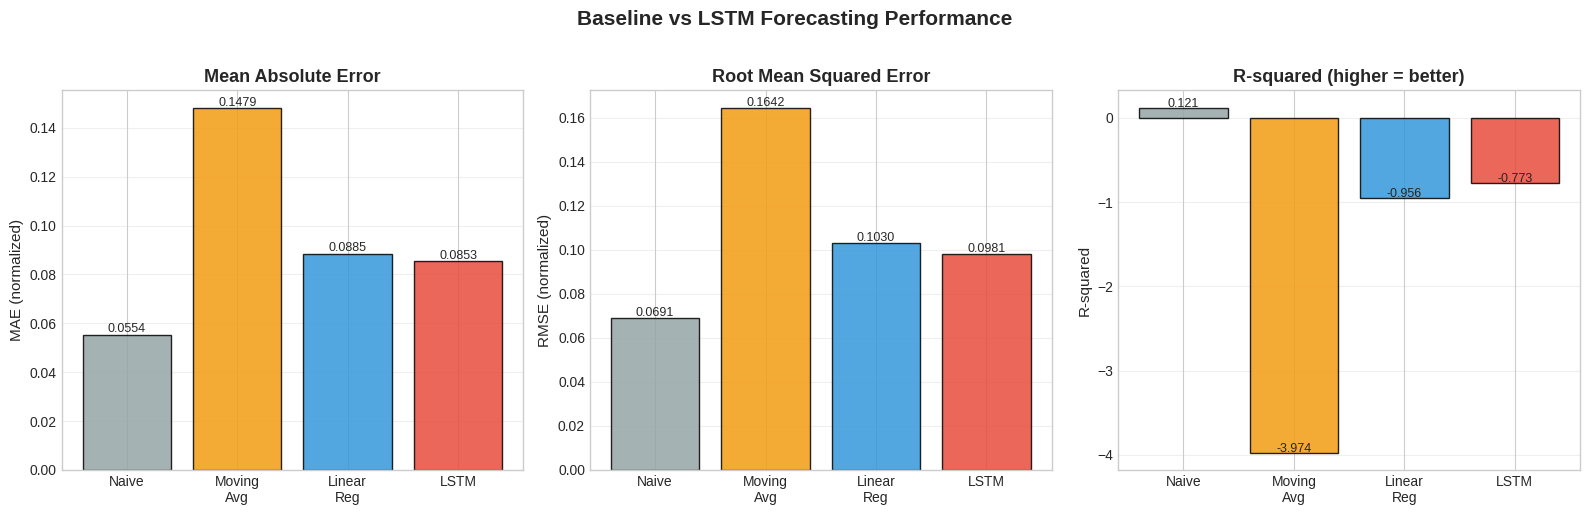

The LSTM should outperform simple baselines, especially for longer horizons.
If naive baseline wins, the horizon may be too short for DL to add value.


In [18]:
# ============================================================
# Section 6b: Bar Chart -- LSTM vs All Baselines
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names = [r['Model'] for r in results]
short_names = ['Naive', 'Moving\nAvg', 'Linear\nReg', 'LSTM']
colors = ['#95A5A6', '#F39C12', '#3498DB', '#E74C3C']

# MAE comparison
mae_vals = [r['MAE'] for r in results]
bars = axes[0].bar(short_names, mae_vals, color=colors, edgecolor='black', alpha=0.85)
axes[0].set_ylabel('MAE (normalized)', fontsize=11)
axes[0].set_title('Mean Absolute Error', fontsize=13, fontweight='bold')
for bar, val in zip(bars, mae_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE comparison
rmse_vals = [r['RMSE'] for r in results]
bars = axes[1].bar(short_names, rmse_vals, color=colors, edgecolor='black', alpha=0.85)
axes[1].set_ylabel('RMSE (normalized)', fontsize=11)
axes[1].set_title('Root Mean Squared Error', fontsize=13, fontweight='bold')
for bar, val in zip(bars, rmse_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

# R2 comparison
r2_vals = [r['R2'] for r in results]
bars = axes[2].bar(short_names, r2_vals, color=colors, edgecolor='black', alpha=0.85)
axes[2].set_ylabel('R-squared', fontsize=11)
axes[2].set_title('R-squared (higher = better)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Baseline vs LSTM Forecasting Performance',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("The LSTM should outperform simple baselines, especially for longer horizons.")
print("If naive baseline wins, the horizon may be too short for DL to add value.")


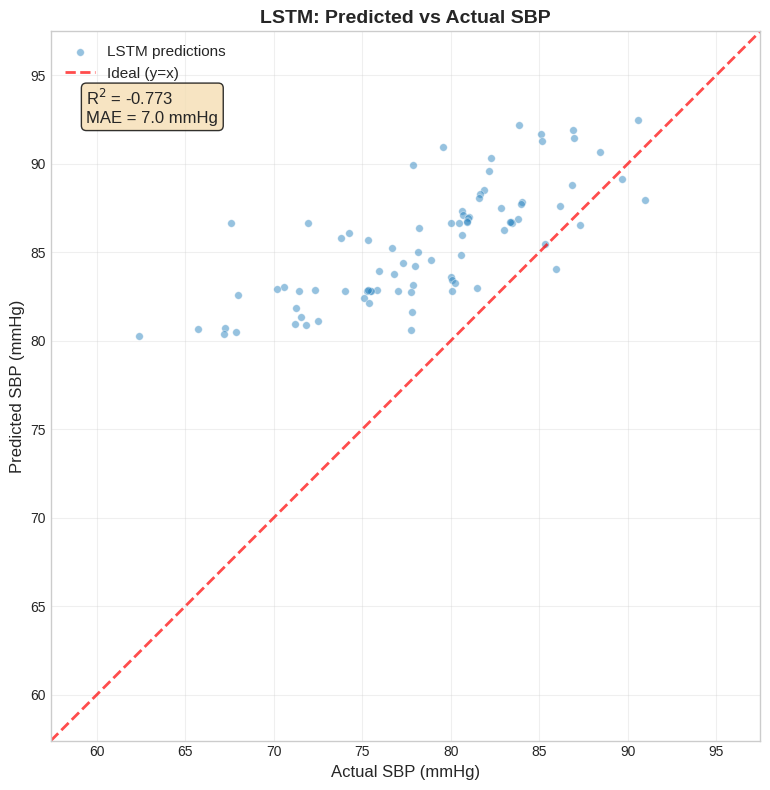

Scatter plot interpretation:
  Points on the diagonal = perfect predictions
  Points above = model over-predicts (predicted > actual)
  Points below = model under-predicts (predicted < actual)
  Cluster far from diagonal = large errors (likely during the crash)


In [19]:
# ============================================================
# Section 6c: Scatter Plot -- Predicted vs Actual
# ============================================================
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test_mmhg, y_pred_lstm_mmhg, alpha=0.5, color='#2E86C1',
           edgecolors='white', linewidth=0.5, s=30, label='LSTM predictions')

# Perfect prediction line
min_val = min(y_test_mmhg.min(), y_pred_lstm_mmhg.min()) - 5
max_val = max(y_test_mmhg.max(), y_pred_lstm_mmhg.max()) + 5
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
        label='Ideal (y=x)', alpha=0.7)

ax.set_xlabel('Actual SBP (mmHg)', fontsize=12)
ax.set_ylabel('Predicted SBP (mmHg)', fontsize=12)
ax.set_title('LSTM: Predicted vs Actual SBP',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Add R2 annotation
r2_lstm = r2_score(y_test_mmhg, y_pred_lstm_mmhg)
mae_lstm = mean_absolute_error(y_test_mmhg, y_pred_lstm_mmhg)
ax.text(0.05, 0.92, f'R$^2$ = {r2_lstm:.3f}\nMAE = {mae_lstm:.1f} mmHg',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Scatter plot interpretation:")
print(f"  Points on the diagonal = perfect predictions")
print(f"  Points above = model over-predicts (predicted > actual)")
print(f"  Points below = model under-predicts (predicted < actual)")
print(f"  Cluster far from diagonal = large errors (likely during the crash)")


## 7. Student Tasks

Complete the following tasks to deepen your understanding of time series
forecasting for clinical applications. Each task builds on the LSTM model
you just trained.

| Task | Description | Difficulty |
|------|-------------|------------|
| T1 | Add Dropout(0.2) after each LSTM layer | :star: |
| T2 | Replace LSTM with GRU -- compare speed and MAE | :star: |
| T3 | Multivariate input: HR + SpO2 + RR -> predict SBP | :star::star: |
| T4 | Multi-step forecast: predict next 6 hours | :star::star: |
| T5 | Add attention layer + visualize attention weights | :star::star::star: |

> **Corresponds to Slides S60 (Lab 2 Exercise Tasks)**


In [20]:
# ============================================================
# Task 1 (Star): Add Dropout(0.2) After Each LSTM Layer
# ============================================================
# Dropout prevents overfitting by randomly "turning off" 20% of neurons
# during training. Like training junior doctors by randomly making
# the senior unavailable -- the team learns to function without any
# single member.
#
# Hint: Insert Dropout layers between LSTM and Dense layers.

def build_lstm_with_dropout(input_shape, dropout_rate=0.2):
    model = models.Sequential([
        layers.LSTM(64, return_sequences=True, input_shape=input_shape),
        layers.Dropout(dropout_rate),   # <-- Add dropout here
        layers.LSTM(32),
        layers.Dropout(dropout_rate),   # <-- And here
        layers.Dense(1)
    ])
    return model

# TODO: Build, compile, train, and compare with the original model
# model_dropout = build_lstm_with_dropout((window_size, 1))
# model_dropout.compile(loss='mse', optimizer='adam', metrics=['mae'])
# history_dropout = model_dropout.fit(X_train_lstm, y_train,
#                                      validation_split=0.2,
#                                      epochs=100, batch_size=32,
#                                      callbacks=[EarlyStopping(patience=10,
#                                                 restore_best_weights=True)])
# y_pred_dropout = model_dropout.predict(X_test_lstm).flatten()
# print(f"Dropout MAE: {mean_absolute_error(y_test, y_pred_dropout):.4f}")
# print(f"Original MAE: {lstm_result['MAE']:.4f}")

# YOUR CODE HERE:



In [21]:
# ============================================================
# Task 2 (Star): Replace LSTM with GRU -- Compare Speed and MAE
# ============================================================
# GRU (Gated Recurrent Unit) is a simplified LSTM:
# - 2 gates instead of 3 (reset gate + update gate)
# - Fewer parameters -> faster training
# - Often similar performance to LSTM
#
# Clinical analogy: GRU is like a more efficient hospital protocol --
# fewer checkpoints but still captures the essential decision points.

def build_gru_forecaster(input_shape):
    model = models.Sequential([
        layers.GRU(64, return_sequences=True, input_shape=input_shape),
        layers.GRU(32),
        layers.Dense(1)
    ])
    return model

# TODO: Build, compile, train, and compare
# import time
# model_gru = build_gru_forecaster((window_size, 1))
# model_gru.compile(loss='mse', optimizer='adam', metrics=['mae'])
#
# start_time = time.time()
# history_gru = model_gru.fit(X_train_lstm, y_train,
#                              validation_split=0.2,
#                              epochs=100, batch_size=32,
#                              callbacks=[EarlyStopping(patience=10,
#                                         restore_best_weights=True)],
#                              verbose=0)
# gru_time = time.time() - start_time
#
# y_pred_gru = model_gru.predict(X_test_lstm).flatten()
# gru_mae = mean_absolute_error(y_test, y_pred_gru)
#
# print(f"GRU Training Time: {gru_time:.1f}s")
# print(f"GRU MAE: {gru_mae:.4f}")
# print(f"LSTM MAE: {lstm_result['MAE']:.4f}")
# print(f"GRU Parameters: {model_gru.count_params():,}")
# print(f"LSTM Parameters: {model.count_params():,}")

# YOUR CODE HERE:



In [22]:
# ============================================================
# Task 3 (Star-Star): Multivariate Input (HR + SpO2 + RR -> SBP)
# ============================================================
# Mrs. Chen's BP doesn't exist in isolation -- heart rate, SpO2,
# and respiratory rate all correlate. A multivariate model uses
# ALL channels as input to predict SBP.
#
# This is like an ICU doctor who considers ALL vitals together,
# not just one number in isolation.

# Hint: Create multivariate sliding windows
# def create_multivariate_windows(data_df, target_col, feature_cols,
#                                  window_size, horizon):
#     """
#     data_df: DataFrame with all vital signs
#     target_col: column to predict (e.g., 'SBP')
#     feature_cols: list of input columns (e.g., ['HR', 'SBP', 'SpO2', 'RR'])
#     """
#     features = data_df[feature_cols].values  # shape: (n_samples, n_features)
#     target = data_df[target_col].values
#
#     # Normalize each feature independently
#     scalers = {}
#     features_scaled = np.zeros_like(features, dtype=np.float64)
#     for i, col in enumerate(feature_cols):
#         s = MinMaxScaler()
#         features_scaled[:, i] = s.fit_transform(features[:, i].reshape(-1, 1)).flatten()
#         scalers[col] = s
#
#     X, y = [], []
#     for i in range(len(features_scaled) - window_size - horizon + 1):
#         X.append(features_scaled[i : i + window_size])  # (window, n_features)
#         y.append(scalers[target_col].transform([[target[i + window_size + horizon - 1]]])[0, 0])
#     return np.array(X), np.array(y), scalers
#
# X_mv, y_mv, scalers_mv = create_multivariate_windows(
#     vitals, 'SBP', ['HR', 'SBP', 'SpO2', 'RR'], window_size, horizon)
#
# # LSTM input shape: (window_size, 4) -- 4 features instead of 1
# model_mv = models.Sequential([
#     layers.LSTM(64, return_sequences=True, input_shape=(window_size, 4)),
#     layers.LSTM(32),
#     layers.Dense(1)
# ])

# YOUR CODE HERE:



In [23]:
# ============================================================
# Task 4 (Star-Star): Multi-Step Forecast (Predict Next 6 Hours)
# ============================================================
# Instead of predicting 1 hour ahead, predict the next 6 HOURS
# (72 samples at 5-min intervals).
#
# Two approaches:
# A) Recursive: predict 1 step, feed it back, predict next step, ...
#    Problem: errors accumulate at each step
# B) Direct: train the model to output 72 values at once
#    Use Dense(72) as the output layer
#
# Clinical significance: 6-hour lead time enables proactive intervention
# (calling the attending, preparing medications, ordering labs).

# Hint for Direct approach:
# multi_horizon = 72  # 6 hours ahead
#
# def create_multi_step_windows(data, window_size, horizon):
#     X, y = [], []
#     for i in range(len(data) - window_size - horizon + 1):
#         X.append(data[i : i + window_size])
#         y.append(data[i + window_size : i + window_size + horizon])
#     return np.array(X), np.array(y)
#
# X_ms, y_ms = create_multi_step_windows(sbp_scaled, window_size, multi_horizon)
#
# model_ms = models.Sequential([
#     layers.LSTM(64, return_sequences=True, input_shape=(window_size, 1)),
#     layers.LSTM(32),
#     layers.Dense(multi_horizon)  # Output 72 values at once
# ])
# model_ms.compile(loss='mse', optimizer='adam')

# YOUR CODE HERE:



In [24]:
# ============================================================
# Task 5 (Star-Star-Star): Add Attention Layer + Visualize Weights
# ============================================================
# The attention mechanism lets the model decide WHICH past timesteps
# are most important for the prediction. This is critical for
# interpretability: "The model focused on the BP dip at hour 32."
#
# Clinical analogy: Like a doctor focusing on the most relevant
# part of a patient's 24-hour chart, not reading every data point equally.

# Hint: Use Keras Attention layer
# class AttentionLayer(layers.Layer):
#     def __init__(self, **kwargs):
#         super().__init__(**kwargs)
#
#     def build(self, input_shape):
#         self.W = self.add_weight(name='att_weight',
#                                   shape=(input_shape[-1], 1),
#                                   initializer='glorot_uniform',
#                                   trainable=True)
#         self.b = self.add_weight(name='att_bias',
#                                   shape=(input_shape[1], 1),
#                                   initializer='zeros',
#                                   trainable=True)
#
#     def call(self, x):
#         # x shape: (batch, timesteps, features)
#         e = tf.nn.tanh(tf.matmul(x, self.W) + self.b)  # (batch, timesteps, 1)
#         alpha = tf.nn.softmax(e, axis=1)                 # attention weights
#         context = tf.reduce_sum(x * alpha, axis=1)       # weighted sum
#         return context, alpha
#
# # Build model with attention
# inputs = layers.Input(shape=(window_size, 1))
# lstm_out = layers.LSTM(64, return_sequences=True)(inputs)
# context, attention_weights = AttentionLayer()(lstm_out)
# output = layers.Dense(1)(context)
# model_att = models.Model(inputs, output)
#
# To visualize attention weights:
# att_model = models.Model(inputs, attention_weights)
# weights = att_model.predict(X_test_lstm[0:1])
# plt.plot(weights.flatten())
# plt.title('Attention Weights Over Time')

# YOUR CODE HERE:



## 8. Gemini AI Exercise

Use Google Colab's built-in **Gemini AI** to explore advanced forecasting
concepts, clinical deployment challenges, and system design thinking.

These three prompts go beyond model building into clinical workflow integration --
the critical gap between "model works in a notebook" and "model saves lives in an ICU."

> **Corresponds to Slides S61 (Lab 2 Clinical Reality Check + Gemini)**


In [25]:
# ============================================================
# Section 8a: Gemini Prompt 1 -- LSTM vs GRU Trade-offs
# ============================================================
try:
    from google.colab import ai

    print("Gemini Prompt 1: LSTM vs GRU for clinical monitoring")
    print("=" * 60)
    response = ai.generate_text(
        "Explain the difference between LSTM and GRU for time series "
        "forecasting. When would you choose each in a clinical monitoring "
        "application? Keep it under 200 words."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("This section works only in Google Colab.")
    print("\nTry this prompt manually in Colab's Gemini sidebar:")
    print("-" * 60)
    print('"Explain the difference between LSTM and GRU for time series')
    print('forecasting. When would you choose each in a clinical monitoring')
    print('application? Keep it under 200 words."')


Gemini Prompt 1: LSTM vs GRU for clinical monitoring


TimeoutException: Requesting secret MODEL_PROXY_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.

In [26]:
# ============================================================
# Section 8b: Gemini Prompt 2 -- Multi-Step Forecasting
# ============================================================
try:
    from google.colab import ai

    print("\nGemini Prompt 2: Multi-step forecasting approaches")
    print("=" * 60)
    response = ai.generate_text(
        "I have an LSTM predicting ICU blood pressure 1 hour ahead with "
        "MAE=5.2 mmHg. I need to predict 6 hours ahead. Suggest 3 "
        "approaches for multi-step forecasting and compare their trade-offs."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("\nTry this prompt manually in Colab's Gemini sidebar:")
    print("-" * 60)
    print('"I have an LSTM predicting ICU blood pressure 1 hour ahead with')
    print('MAE=5.2 mmHg. I need to predict 6 hours ahead. Suggest 3')
    print('approaches for multi-step forecasting and compare their trade-offs."')


In [27]:
# ============================================================
# Section 8c: Gemini Prompt 3 -- Clinical Early Warning Design
# ============================================================
try:
    from google.colab import ai

    print("\nGemini Prompt 3: Design a clinical early warning system")
    print("=" * 60)
    response = ai.generate_text(
        "Design a clinical early warning system that uses AI vital sign "
        "predictions. What threshold should trigger an alert? How do you "
        "balance sensitivity vs false alarm rate? Consider nurse workflow."
    )
    print(response)

except ImportError:
    print("google.colab.ai is not available in this environment.")
    print("\nTry this prompt manually in Colab's Gemini sidebar:")
    print("-" * 60)
    print('"Design a clinical early warning system that uses AI vital sign')
    print('predictions. What threshold should trigger an alert? How do you')
    print('balance sensitivity vs false alarm rate? Consider nurse workflow."')


## 9. Bonus: ARIMA Comparison

**ARIMA(p,d,q)** is the classical statistical approach to time series forecasting:
- **p** (autoregressive order): How many past values to use
- **d** (differencing order): How many times to difference for stationarity
- **q** (moving average order): How many past forecast errors to use

ARIMA has predicted hospital admissions, disease outbreaks, and patient volumes
for decades. It's interpretable, well-understood, and doesn't need GPUs.

**When does ARIMA win?**
- Small univariate datasets
- Linear trends and fixed seasonal patterns
- When interpretability > marginal accuracy gain

**When does LSTM win?**
- Nonlinear dynamics (ICU patient deterioration)
- Multivariate inputs (multiple vital sign channels)
- Large datasets with complex temporal patterns

> **Corresponds to Slides S23-S25 (Part 2: ARIMA/SARIMA)**


In [28]:
# ============================================================
# Section 9a: Fit ARIMA(2,1,2) on SBP
# ============================================================
# Use only the training portion of the time series for fitting
train_end = split_idx + window_size
sbp_train_arima = vitals['SBP'].values[:train_end]
sbp_test_arima = vitals['SBP'].values[train_end : train_end + len(y_test)]

print(f"ARIMA fitting:")
print(f"  Training samples: {len(sbp_train_arima)}")
print(f"  Test samples:     {len(sbp_test_arima)}")

# Fit ARIMA(2,1,2)
# p=2: use last 2 values (autoregressive)
# d=1: difference once for stationarity
# q=2: use last 2 forecast errors (moving average)
try:
    arima_model = ARIMA(sbp_train_arima, order=(2, 1, 2))
    arima_fit = arima_model.fit()

    print(f"\nARIMA(2,1,2) Model Summary:")
    print(f"  AIC: {arima_fit.aic:.2f}")
    print(f"  BIC: {arima_fit.bic:.2f}")

    # Forecast on test period
    n_forecast = min(len(sbp_test_arima), len(y_test))
    arima_forecast = arima_fit.forecast(steps=n_forecast)

    # Evaluate
    arima_mae = mean_absolute_error(sbp_test_arima[:n_forecast], arima_forecast)
    arima_rmse = np.sqrt(mean_squared_error(sbp_test_arima[:n_forecast], arima_forecast))
    arima_r2 = r2_score(sbp_test_arima[:n_forecast], arima_forecast)

    print(f"\nARIMA Forecast Metrics (in mmHg):")
    print(f"  MAE:  {arima_mae:.2f} mmHg")
    print(f"  RMSE: {arima_rmse:.2f} mmHg")
    print(f"  R2:   {arima_r2:.4f}")

except Exception as e:
    print(f"ARIMA fitting failed: {e}")
    print("This can happen with non-standard data patterns.")
    print("Falling back to a simple exponential smoothing comparison.")
    arima_forecast = None


In [29]:
# ============================================================
# Section 9b: Visualize ARIMA vs LSTM
# ============================================================
if arima_forecast is not None and len(arima_forecast) > 0:
    n_plot = min(len(sbp_test_arima), len(y_test), len(arima_forecast))
    test_time_arima = time_hours[train_end : train_end + n_plot]

    fig, axes = plt.subplots(2, 1, figsize=(16, 10))

    # Top: Time series comparison
    axes[0].plot(test_time_arima, sbp_test_arima[:n_plot],
                 color='#2E86C1', linewidth=1.5, label='Actual SBP')
    axes[0].plot(test_time_arima, arima_forecast[:n_plot],
                 color='#27AE60', linewidth=1.5, linestyle='--', label='ARIMA(2,1,2)')
    axes[0].plot(test_time[:n_plot], y_pred_lstm_mmhg[:n_plot],
                 color='#E74C3C', linewidth=1.5, linestyle='--', label='LSTM')

    axes[0].axvline(x=36, color='red', linestyle=':', linewidth=2, alpha=0.5)
    axes[0].set_ylabel('SBP (mmHg)', fontsize=12)
    axes[0].set_title('ARIMA vs LSTM Forecasting -- Mrs. Chen SBP',
                       fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Bottom: Error comparison
    arima_errors = np.abs(sbp_test_arima[:n_plot] - arima_forecast[:n_plot])
    lstm_errors = np.abs(y_test_mmhg[:n_plot] - y_pred_lstm_mmhg[:n_plot])

    axes[1].plot(test_time_arima[:len(arima_errors)], arima_errors,
                 color='#27AE60', linewidth=1.0, alpha=0.8, label='ARIMA |Error|')
    axes[1].plot(test_time[:len(lstm_errors)], lstm_errors,
                 color='#E74C3C', linewidth=1.0, alpha=0.8, label='LSTM |Error|')

    axes[1].axvline(x=36, color='red', linestyle=':', linewidth=2, alpha=0.5)
    axes[1].set_xlabel('Time (hours)', fontsize=12)
    axes[1].set_ylabel('Absolute Error (mmHg)', fontsize=12)
    axes[1].set_title('Forecast Error Over Time', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Summary comparison
    lstm_mae_mmhg = mean_absolute_error(y_test_mmhg[:n_plot], y_pred_lstm_mmhg[:n_plot])

    print("=" * 60)
    print("ARIMA vs LSTM COMPARISON")
    print("=" * 60)
    print(f"  {'Metric':<20} {'ARIMA':>12} {'LSTM':>12}")
    print(f"  {'-'*46}")
    print(f"  {'MAE (mmHg)':<20} {arima_mae:>12.2f} {lstm_mae_mmhg:>12.2f}")
    print(f"  {'RMSE (mmHg)':<20} {arima_rmse:>12.2f} {np.sqrt(mean_squared_error(y_test_mmhg[:n_plot], y_pred_lstm_mmhg[:n_plot])):>12.2f}")
    print(f"  {'R2':<20} {arima_r2:>12.4f} {r2_score(y_test_mmhg[:n_plot], y_pred_lstm_mmhg[:n_plot]):>12.4f}")
    print(f"\nKey takeaway:")
    print(f"  ARIMA is linear and stationary -- it struggles with the nonlinear crash.")
    print(f"  LSTM captures complex dynamics but needs more data and compute.")
    print(f"  In practice: ARIMA for stable patients, LSTM for ICU deterioration.")

else:
    print("ARIMA forecast was not generated. Skipping comparison plot.")
    print("This is expected if the data was too non-stationary for ARIMA to fit.")


## 10. Summary & Self-Check

### Key Takeaways (Matching Slide S75)

1. **Regression vs Classification**: Classification predicts a LABEL (normal/abnormal), regression predicts a NUMBER (BP=128.5 mmHg). Same ML pipeline, different output layer (linear vs softmax) and loss function (MSE vs cross-entropy).

2. **Regularization prevents overconfident models**: Ridge (L2) shrinks all coefficients, Lasso (L1) performs automatic feature selection, Elastic Net combines both. Essential when features > patients.

3. **Time series decomposition reveals hidden patterns**: Trend (Mrs. Chen's gradual decline) + Seasonality (circadian rhythm) + Residual (noise). The trend is the clinically actionable signal.

4. **ARIMA and SARIMA are classical but powerful**: ARIMA(p,d,q) is 50+ years old but still wins on small, univariate data. SARIMA adds seasonal awareness for cyclical clinical patterns.

5. **LSTM captures nonlinear temporal dynamics**: Forget gate decides what to remember, input gate what to learn, output gate what to predict. For regression: Dense(1) with linear activation and MSE loss.

6. **Early warning systems need more than accuracy**: 93.6% of clinical alerts are overridden. The best AI prediction is useless without proper threshold design, alert management, and clinical workflow integration.

### Key Numbers (Matching Slide S76)

| Number | Significance |
|--------|-------------|
| 6 hours | Early warning lead time -- how far ahead AI can predict deterioration |
| 93.6% | Alert override rate -- the alert fatigue paradox |
| AUROC 0.86 | XGBoost MI risk prediction on UK Biobank (>500K patients) |
| F1 = 88% | Time-Aware LSTM for multi-disease EHR prediction |
| 98% | DB-LSTM ECG forecast accuracy on edge hardware |
| AUROC 0.97 | Fall risk prediction with wearables (RF + DL) |

### Self-Check Checklist

- [ ] I can differentiate regression from classification (output, loss, metrics)
- [ ] I understand regularization: Ridge, Lasso, Elastic Net and when to use each
- [ ] I can decompose a time series into trend, seasonal, and residual components
- [ ] I can interpret ACF/PACF plots and the ADF stationarity test
- [ ] I built and trained an LSTM for blood pressure forecasting
- [ ] I compared LSTM against baselines (naive, moving average, linear regression)
- [ ] I understand why ARIMA works for simple patterns and LSTM for complex dynamics
- [ ] I know why alert fatigue (93.6% override) makes deployment harder than modeling

### Next Week Preview

**Week 7: Explainable AI (XAI) -- SHAP, LIME, and Grad-CAM**
- This week: the model PREDICTS (SBP will crash in 6 hours)
- Next week: the model must EXPLAIN (87% sepsis risk -- but WHY? Which indicators?)
- Clinical scenario: "AI predicts 87% sepsis risk. The ICU attending asks: Why? Should I trust this?"
- Key methods: SHAP, LIME, feature importance, Grad-CAM
- Prepare: review Random Forest feature importance and LSTM architecture


In [30]:
# ============================================================
# Final Verification
# ============================================================
print("=" * 60)
print("Congratulations! You've completed the Week 6 Notebook!")
print("Regression and Time Series Forecasting for ICU Vital Signs")
print("=" * 60)

print(f"\nDataset: Synthetic ICU Vital Signs (Mrs. Chen, 48 hours)")
print(f"  Duration:    {duration_hours} hours ({n_samples} samples)")
print(f"  Channels:    HR, SBP, SpO2, RR")
print(f"  Key event:   Deterioration at hour 36")

print(f"\nForecasting Configuration:")
print(f"  Window size: {window_size * sample_interval_min / 60:.0f} hours ({window_size} samples)")
print(f"  Horizon:     {horizon * sample_interval_min / 60:.0f} hour(s) ({horizon} samples)")
print(f"  Train/test:  {X_train.shape[0]} / {X_test.shape[0]} windows (time-based split)")

print(f"\nModel Comparison (normalized MAE):")
print(f"  {'Model':<30} {'MAE':>8}")
print(f"  {'-'*40}")
for r in results:
    print(f"  {r['Model']:<30} {r['MAE']:>8.4f}")

print(f"\nKey lessons from this week:")
print(f"  1. Regression = predict a NUMBER, not a label")
print(f"  2. Time series split must be chronological (no data leakage)")
print(f"  3. Simple baselines are hard to beat for short horizons")
print(f"  4. LSTM captures nonlinear dynamics that ARIMA cannot")
print(f"  5. Decomposition reveals the trend hidden in noise")
print(f"  6. 93.6% alert override rate = technology alone isn't enough")

print(f"\nReturning to Mrs. Chen's scenario:")
print(f"  The LSTM model can track her SBP trajectory and predict")
print(f"  the coming crash. But the prediction must reach the nurse,")
print(f"  the nurse must trust it, and the hospital must have a protocol.")
print(f"  Technology is necessary but not sufficient.")

print(f"\nNext week: Explainable AI -- WHY did the model predict this?")
